In [1]:
# Install librosa the audio processing library
!pip install librosa --quiet

In [2]:
# Necessary Libraries
import os
import kagglehub
import pickle
import json
import warnings
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')

In [3]:
# Constants
SAMPLE_RATE = 16000
CLIP_DURATION = 3    
N_MFCC = 13    
CONFIDENCE_THRESHOLD = 0.75 

In [4]:
# Dataset 1(for cough & wheeze)
path1 = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")
print("Path to dataset files:", path1)

Path to dataset files: /kaggle/input/datasets/vbookshelf/respiratory-sound-database


In [5]:
# Dataset 2(for snore)
path2 = kagglehub.dataset_download("tareqkhanemu/snoring")
print("Path to dataset files:", path2)

Path to dataset files: /kaggle/input/datasets/tareqkhanemu/snoring


In [6]:
path1 = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"

In [7]:
path2 = "/kaggle/input/datasets/tareqkhanemu/snoring/Snoring Dataset"

In [8]:
# Dataset 1 Info
ICBHI_PATH = None
if os.path.exists(path1):
    wav_count = len([f for f in os.listdir(path1) if f.endswith('.wav')])    
    if wav_count > 0:
        ICBHI_PATH = path1
        print(f"ICBHI dataset found")
        print(f"Path: {ICBHI_PATH}")
        print(f"Files: {wav_count} audio files")
    else:
        print(f"Path exists, but no .wav files were found in: {path1}")
else:
    print(f"ICBHI dataset not found at the provided path: {path1}")
    
print()

ICBHI dataset found
Path: /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
Files: 920 audio files



In [9]:
# Load Dataset 1
def extract_mfcc(audio, sr, n_mfcc=N_MFCC):
    """
    Convert raw audio → 13 summary numbers which are MFCC features.    
    Think of MFCC as a fingerprint for the sound.
    Each number captures a different property: loudness, pitch, texture, etc.
    """
    mfcc      = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)  
    mfcc_std  = np.std(mfcc, axis=1)   
    return np.concatenate([mfcc_mean, mfcc_std]) 

In [10]:
def read_icbhi_label(txt_path):
    """
    Read the annotation file and figure out what sounds are in it.
    Returns: 'wheeze', 'crackle', or 'normal'
    """
    has_wheeze  = False
    has_crackle = False
    try:
        with open(txt_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 4:
                    crackle = parts[2].strip()
                    wheeze  = parts[3].strip()
                    if wheeze  == '1': has_wheeze  = True
                    if crackle == '1': has_crackle = True
    except:
        pass
    if has_wheeze:  return 'wheeze'
    if has_crackle: return 'cough' 
    return 'normal'

In [11]:
def load_icbhi_dataset(path, max_per_class=250):
    """
    Load audio files from ICBHI and extract features.
    max_per_class: limit files per class to keep training balanced.
    """
    X, y = [], []
    counts = {'wheeze': 0, 'cough': 0, 'normal': 0}
    errors = 0

    wav_files = sorted([f for f in os.listdir(path) if f.endswith('.wav')])
    print(f"Found {len(wav_files)} audio files in ICBHI")

    for filename in wav_files:
        wav_path = os.path.join(path, filename)
        txt_path = wav_path.replace('.wav', '.txt')

        if not os.path.exists(txt_path):
            continue

        label = read_icbhi_label(txt_path)
        
        if counts[label] >= max_per_class:
            continue

        try:
            audio, sr = librosa.load(wav_path, sr=SAMPLE_RATE,
                                     duration=CLIP_DURATION)
            target_len = SAMPLE_RATE * CLIP_DURATION
            if len(audio) < target_len:
                audio = np.pad(audio, (0, target_len - len(audio)))

            features = extract_mfcc(audio, sr)
            X.append(features)
            y.append(label)
            counts[label] += 1

        except Exception as e:
            errors += 1

    print(f"ICBHI loaded = wheeze: {counts['wheeze']}, "
          f"cough: {counts['cough']}, normal: {counts['normal']}")
    if errors > 0:
        print(f"(skipped {errors} unreadable files — normal)")
    return X, y

In [12]:
X_icbhi, y_icbhi = load_icbhi_dataset(ICBHI_PATH)
print(f"Total samples: {len(X_icbhi)}")

Found 920 audio files in ICBHI
ICBHI loaded = wheeze: 250, cough: 250, normal: 250
Total samples: 750


In [13]:
# Dataset 2 Info
SNORING_PATH = None
if os.path.exists(path2):
    snore_dir  = os.path.join(path2, '1')
    normal_dir = os.path.join(path2, '0')   
    if os.path.exists(snore_dir):
        snore_count = len([f for f in os.listdir(snore_dir) if f.endswith('.wav')])
        print(f"Snoring dataset found")
        print(f"Path: {path2}")
        print(f"Snoring clips: {snore_count} files")
        SNORING_PATH = path2
    else:
        all_wavs = []
        for root, dirs, files in os.walk(path2):
            all_wavs.extend([f for f in files if f.endswith('.wav')])
        
        if all_wavs:
            print(f"Snoring dataset found at: {path2} (Alternative structure)")
            print(f"Total wav files: {len(all_wavs)}")
            SNORING_PATH = path2
        else:
            print(f"Path exists, but no .wav files were found in: {path2}")

else:
    print(f"Snoring dataset not found at the provided path: {path2}")

print()

Snoring dataset found
Path: /kaggle/input/datasets/tareqkhanemu/snoring/Snoring Dataset
Snoring clips: 500 files



In [14]:
# Load Dataset 2
def load_snoring_dataset(base_path, max_snore=250):
    """
    Load snoring dataset.
    Folder '1' = snoring sounds
    Folder '0' = non-snoring, we skip these because ICBHI already gives us normal
    """
    X, y = [], []
    count = 0
    errors = 0

    snore_folder = os.path.join(base_path, '1')

    if not os.path.exists(snore_folder):
        for root, dirs, files in os.walk(base_path):
            for fname in files:
                if fname.endswith('.wav') and count < max_snore:
                    fpath = os.path.join(root, fname)
                    try:
                        audio, sr = librosa.load(fpath, sr=SAMPLE_RATE,
                                                 duration=CLIP_DURATION)
                        target_len = SAMPLE_RATE * CLIP_DURATION
                        if len(audio) < target_len:
                            audio = np.pad(audio, (0, target_len - len(audio)))
                        features = extract_mfcc(audio, sr)
                        X.append(features)
                        y.append('snore')
                        count += 1
                    except:
                        errors += 1
        print(f"Snoring loaded = snore: {count}")
        return X, y

    wav_files = [f for f in os.listdir(snore_folder) if f.endswith('.wav')]
    print(f"Found {len(wav_files)} snoring audio files")

    for filename in wav_files:
        if count >= max_snore:
            break
        fpath = os.path.join(snore_folder, filename)
        try:
            audio, sr = librosa.load(fpath, sr=SAMPLE_RATE,
                                     duration=CLIP_DURATION)
            target_len = SAMPLE_RATE * CLIP_DURATION
            if len(audio) < target_len:
                audio = np.pad(audio, (0, target_len - len(audio)))
            features = extract_mfcc(audio, sr)
            X.append(features)
            y.append('snore')
            count += 1
        except:
            errors += 1

    print(f"Snoring loaded = snore: {count}")
    if errors > 0:
        print(f"(skipped {errors} files — normal)")
    return X, y

In [15]:
X_snore, y_snore = load_snoring_dataset(SNORING_PATH)
print(f"Snoring done! Total samples: {len(X_snore)}")

Found 500 snoring audio files
Snoring loaded = snore: 250
Snoring done! Total samples: 250


In [16]:
# Merge ICBHI & Snoring into single arrays
X_all = np.array(X_icbhi + X_snore)  
y_all = np.array(y_icbhi + y_snore) 

In [17]:
classes, counts = np.unique(y_all, return_counts=True)
total = len(y_all)
for cls, cnt in zip(classes, counts):
    print(f"{cls:8s}: {cnt:4d} samples")

cough   :  250 samples
normal  :  250 samples
snore   :  250 samples
wheeze  :  250 samples


In [18]:
print(f"TOTAL: {total} samples")
print(f"Features: {X_all.shape[1]} numbers per sample")

TOTAL: 1000 samples
Features: 26 numbers per sample


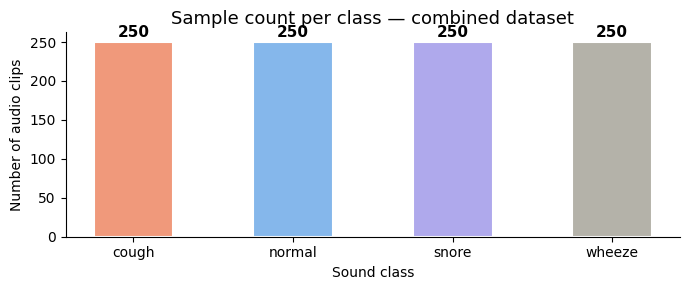

Dataset combined successfully!


In [19]:
# Visualize
fig, ax = plt.subplots(figsize=(7, 3))
colors  = ['#F0997B', '#85B7EB', '#AFA9EC', '#B4B2A9']
bars    = ax.bar(classes, counts, color=colors[:len(classes)], width=0.5, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Sample count per class — combined dataset', fontsize=13)
ax.set_ylabel('Number of audio clips')
ax.set_xlabel('Sound class')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/class_balance.png', dpi=120)
plt.show()
print("Dataset combined successfully!")

In [20]:
# Prepare data for training
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_all)
print("Label encoding:")
for num, name in enumerate(encoder.classes_):
    print(f"{num} → {name}")

Label encoding:
0 → cough
1 → normal
2 → snore
3 → wheeze


In [21]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

In [22]:
# 80% used for teaching the model, 20% kept secret to test it
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_encoded  
)

In [23]:
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 800 samples
Test set: 200 samples


In [24]:
# hidden_layer_sizes=(64, 32)
# Layer 1: 64 neurons, Layer 2: 32 neurons, Output:  4 neurons         
model = MLPClassifier(
    hidden_layer_sizes = (64, 32),
    activation = 'relu',        
    solver = 'adam',       
    max_iter = 500,           
    random_state = 42,
    early_stopping = True,          
    validation_fraction = 0.1,
    n_iter_no_change = 20,
    verbose = False
)

In [25]:
model.fit(X_train, y_train)
train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test,  y_test)

In [26]:
print(f"Training accuracy: {train_acc*100:.1f}%")
print(f"Test accuracy: {test_acc*100:.1f}%")

Training accuracy: 70.6%
Test accuracy: 60.0%


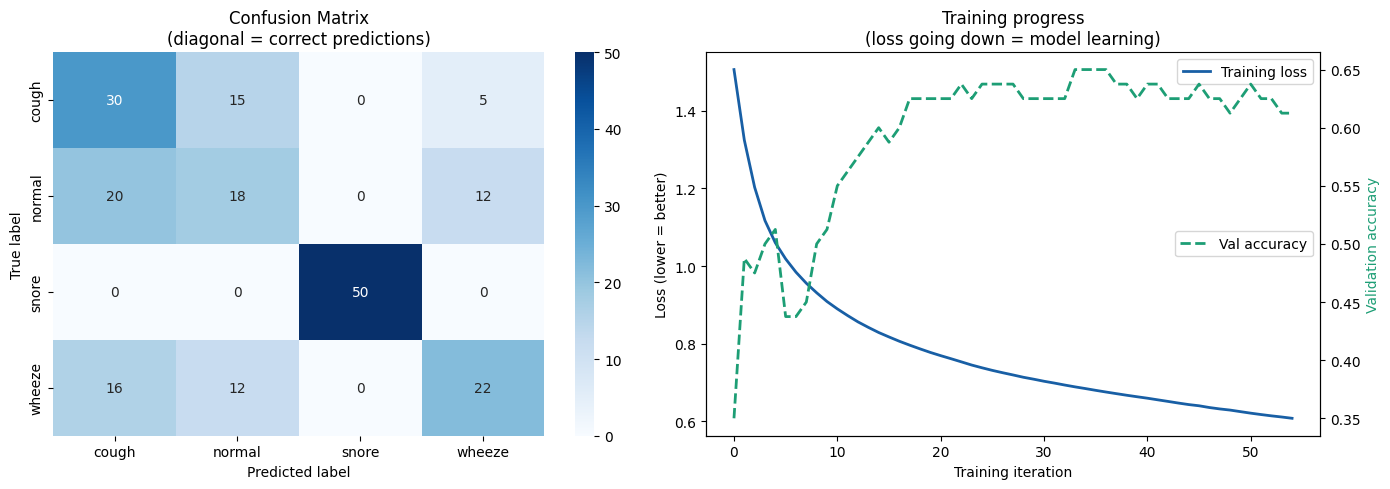

In [27]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
y_pred = model.predict(X_test)
cm     = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = encoder.classes_,
    yticklabels = encoder.classes_,
    ax = axes[0]
)
axes[0].set_title('Confusion Matrix\n(diagonal = correct predictions)', fontsize=12)
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Training Loss Curve
axes[1].plot(model.loss_curve_, color='#185FA5', linewidth=2, label='Training loss')
if hasattr(model, 'validation_scores_') and model.validation_scores_:
    ax2 = axes[1].twinx()
    ax2.plot(model.validation_scores_, color='#1D9E75', linewidth=2, linestyle='--', label='Val accuracy')
    ax2.set_ylabel('Validation accuracy', color='#1D9E75')
    ax2.legend(loc='center right')
axes[1].set_title('Training progress\n(loss going down = model learning)', fontsize=12)
axes[1].set_xlabel('Training iteration')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend(loc='upper right')
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/training_results.png', dpi=120)
plt.show()

In [28]:
print(classification_report(y_test, y_pred, target_names = encoder.classes_))

              precision    recall  f1-score   support

       cough       0.45      0.60      0.52        50
      normal       0.40      0.36      0.38        50
       snore       1.00      1.00      1.00        50
      wheeze       0.56      0.44      0.49        50

    accuracy                           0.60       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.60      0.60      0.60       200

